In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from scipy.spatial.distance import pdist

In [ ]:
N = 10000
X,t = make_swiss_roll(n_samples=N, noise=0.0)

X=X[:,[0,2]]

X = (X-X.mean())/X.std()

X=torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

sigma_max = pdist(X_np).max()
sigma_min = 0.01

Sigma max: 3.6742809288415335, Sigma min: 0.01


In [8]:
def get_sigma(t):

    return sigma_min * (sigma_max/sigma_min)**t

In [39]:
def train_model(
  optimizer_name="Adam",
  lr = 5e-4,
  batch_size = 100,
  width = 128,
  depth = 2,
  num_epochs = 10000      
):
    dataset = TensorDataset(X)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    layers = []

    layers.append(nn.Linear(3,width))
    layers.append(nn.ReLU())

    for _ in range(depth-1):
        layers.append(nn.Linear(width,width))
        layers.append(nn.ReLU())


    layers.append(nn.Linear(width,2))

    model = nn.Sequential(*layers)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            
            batch_size_current = x_batch.shape[0]
            
            t = torch.rand(batch_size_current,1)

            sigma = get_sigma(t)

            noise = torch.randn_like(x_batch)
            
            x_noisy = x_batch + sigma * noise
            
            target = -noise / sigma

            model_input = torch.cat([x_noisy, sigma], dim=1)

            score_pred = model(model_input)

            loss_per_sample = ((score_pred - target) ** 2).sum(dim=1)

            weights = sigma.squeeze() ** 2

            loss = (weights * loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

    return model, loss_history


In [40]:
model, loss_history = train_model()

In [41]:
def g(t):

    sigma = get_sigma(t)

    return (sigma * np.sqrt(2*np.log(sigma_max/sigma_min)))

In [42]:
n_samples=5000
n_steps=1000

model.eval()

dt = 1.0/n_steps

x = torch.randn(n_samples, 2)*sigma_max

with torch.no_grad():


        for i in range(n_steps):

            t = 1 - i/n_steps


            t_tensor = torch.full((n_samples,1), t)


            sigma = get_sigma(t_tensor)


            g_val = g(t_tensor)


            model_input = torch.cat([x, sigma], dim=1)


            score = model(model_input)


            noise = torch.randn_like(x)
            
            x = (x+(g_val**2)*score*dt+g_val*torch.sqrt(torch.tensor(dt))*noise)


Forward SDE

dX_t​ = f(x,t)*dt + g(t)*dW_t​

Fokker-Planck Equation

∂p​/∂t = −∇ ⋅ (f*p) + (1/2) * ​(g^2) * (∇^2 p)

Introduce Reverse Time

τ = T − t

∂ / ∂τ​ = − ∂ / ∂t​

Therefore, the Fokker-Planck in reverse time

∂p / ∂τ = ∇⋅(f*p) − (1/2) * ​(g^2) * (∇^2 p)

Consider a Reverse SDE in the following form

dX_τ ​= b(x,τ) * dτ + g * dWˉ; where b is unknown

The associated Fokker-Planck equation for this reverse SDE:

∂p / ∂τ = -∇⋅(b*p) + (1/2) * ​(g^2) * (∇^2 p)

Equating the Fokker-Planck in reverse time and Fokker-Planck for the reverse SDE, we obtain b (also using the fact that ∇^2 p = ∇ ⋅ (p * ∇logp)):

b = -f + (g^2) * ∇(log p) in τ

b = f - (g^2) * ∇(log p) in t 

Since we have used variance exploding, in our case, f = 0

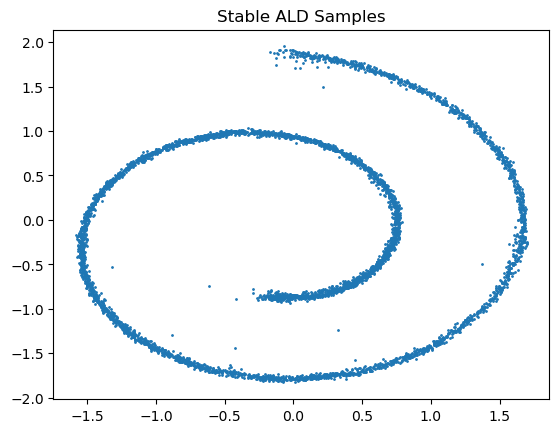

In [43]:
samples = x.detach().cpu().numpy()

plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.title("Stable ALD Samples")
plt.show()


Visually, the generated samples are more refined and closer to the original in this case, when compared to both the single as well as discrete multi-noise levels.


In [44]:
bins = 100
H_real, xedges, yedges = np.histogram2d(
    X[:,0], X[:,1],
    bins=bins,
    density=True
)


H_generated, _, _ = np.histogram2d(
    samples[:,0],
    samples[:,1],
    bins=[xedges, yedges],
    density=True
)

difference = np.sum(np.abs(H_real - H_generated))
print(difference)


606.6053089145388


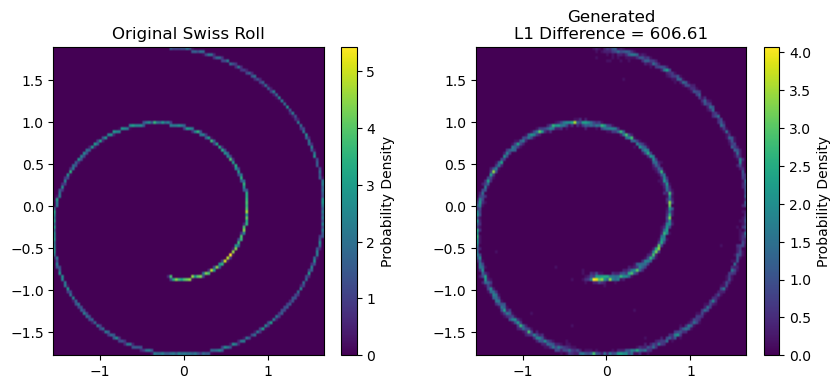

In [45]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im1= ax[0].imshow(
    H_real.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[0].set_title("Original Swiss Roll")

im2=ax[1].imshow(
    H_generated.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]]
)
ax[1].set_title(f"Generated\nL1 Difference = {difference:.2f}")

fig.colorbar(im1, ax=ax[0], label="Probability Density")
fig.colorbar(im2, ax=ax[1], label="Probability Density")
plt.show()

The L1 difference has reduced from 729 to 606 when we switch from multi to continuous-noise levels and reverse SDE sampling